  Cloning https://github.com/jaredwinick/img2vec-keras.git to /tmp/pip-req-build-igadzhgu
  Running command git clone --filter=blob:none --quiet https://github.com/jaredwinick/img2vec-keras.git /tmp/pip-req-build-igadzhgu
  Resolved https://github.com/jaredwinick/img2vec-keras.git to commit 80c56b2e1b698e36c26c4015e8b21216fb4cafbb
  Preparing metadata (setup.py) ... done
  Created wheel for img2vec_keras: filename=img2vec_keras-0.2-py3-none-any.whl size=6197 sha256=dbc1f35d5f7df7522c4a31b8cb6a002c6ecd1f92cd1d3c3745a874717514aada
  Stored in directory: /tmp/pip-ephem-wheel-cache-qnb7i18b/wheels/17/7c/13/31e411a0eb930500d8692d304315f500efab780dbff12ac673
Successfully built img2vec_keras


Downloading...
From (original): https://drive.google.com/uc?id=1Madin3qXe3Xexox5qOhASGulFR2wvsFz
From (redirected): https://drive.google.com/uc?id=1Madin3qXe3Xexox5qOhASGulFR2wvsFz&confirm=t&uuid=213146a8-ec67-4d0b-a5d8-31126ab20e5e
To: /content/101_ObjectCategories.tar.gz
100%|██████████| 132M/132M [00:03<00:00, 40.8MB/s]


102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Найдено изображений: 291
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] KL divergence after 250 iterations with early exaggeration: 51.209007
[t-SNE] KL divergence after 1600 iterations: 0.345555


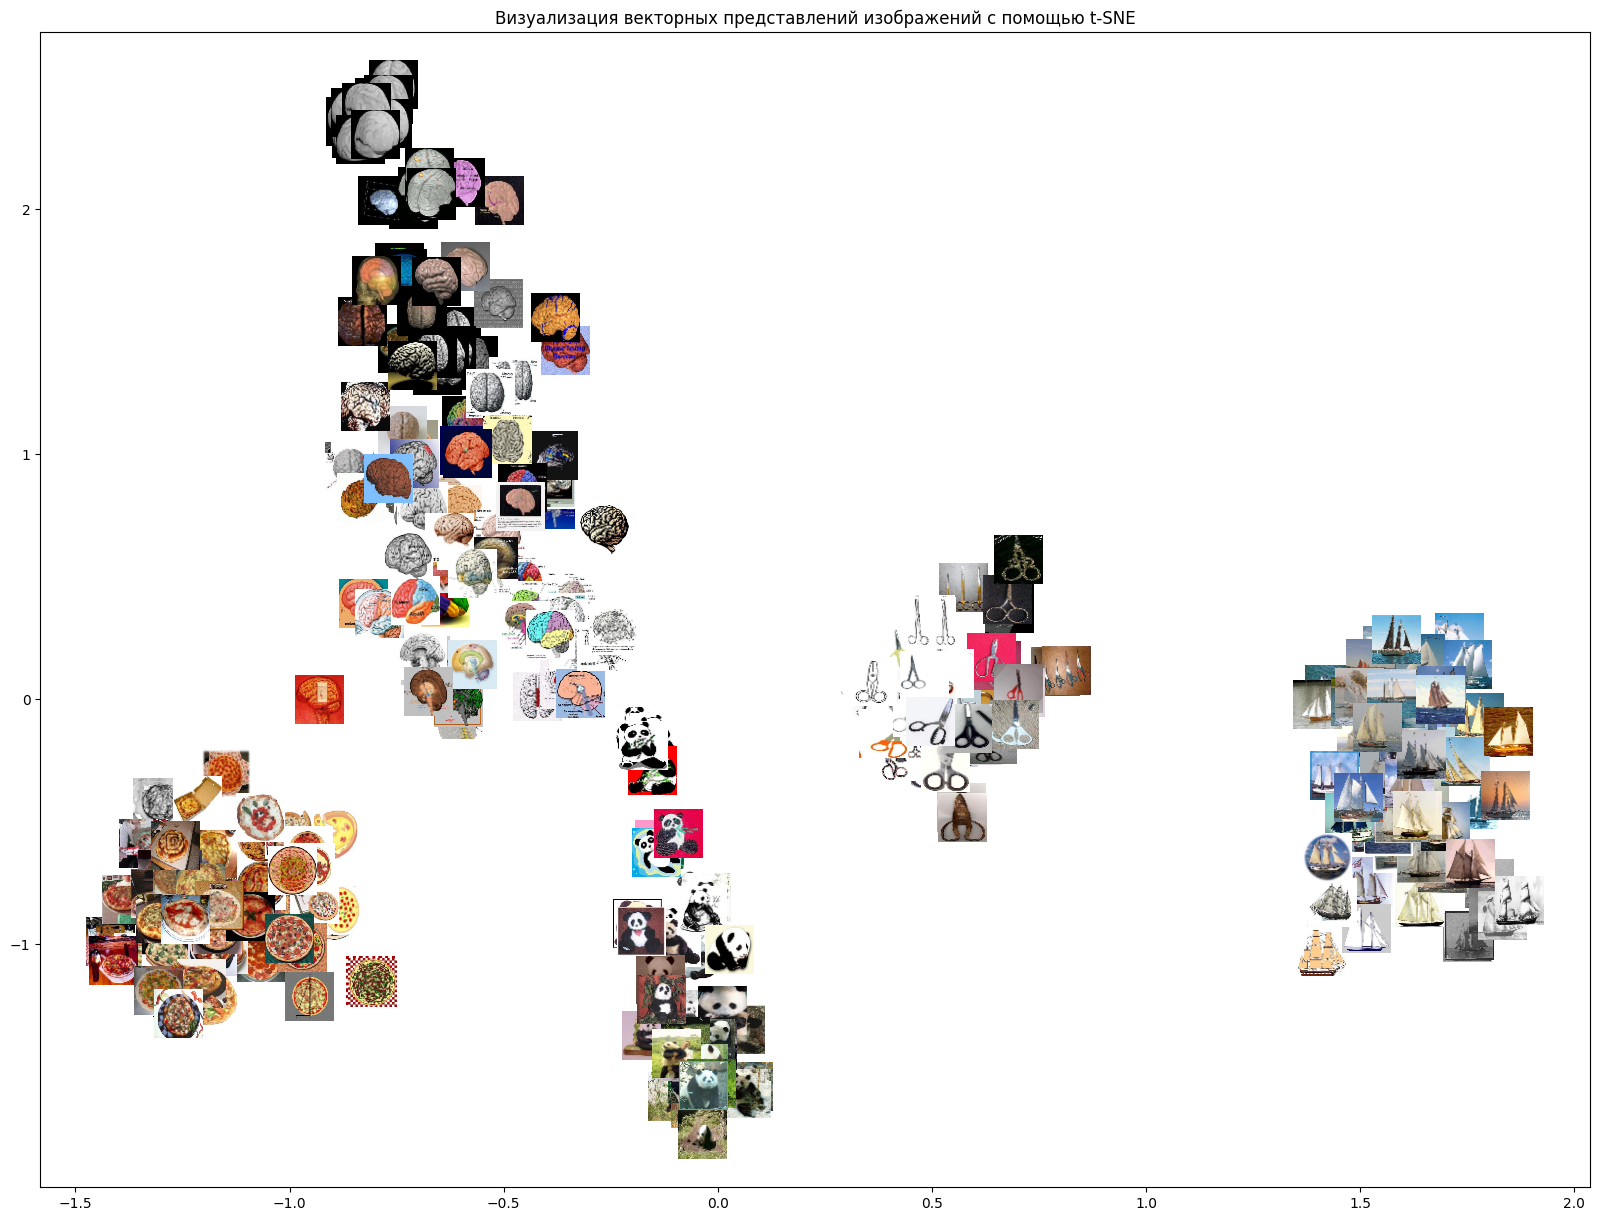

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Разные изображения: 0.257
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
Похожие изображения: 0.900


In [1]:
# Установка необходимых библиотек
!pip install git+https://github.com/jaredwinick/img2vec-keras.git
!pip install gdown

import gdown
import glob
import numpy as np
import matplotlib.pyplot as plt
from img2vec_keras import Img2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import cv2
import os

# Загрузка датасета
url = 'https://drive.google.com/uc?id=1Madin3qXe3Xexox5qOhASGulFR2wvsFz'
output = '101_ObjectCategories.tar.gz'
gdown.download(url, output, quiet=False)

# Распаковка архива
!tar -xzf 101_ObjectCategories.tar.gz
!rm 101_ObjectCategories.tar.gz

# Инициализация модели для получения векторных представлений
img2vec = Img2Vec()

# Выборка классов для анализа
image_classes = ['pizza', 'schooner', 'scissors', 'panda', 'brain']
image_paths = []

# Формирование списка путей к изображениям
for image_class in image_classes:
    image_paths.extend(glob.glob(f'101_ObjectCategories/{image_class}/*.jpg'))

print(f'Найдено изображений: {len(image_paths)}')

# Извлечение векторных представлений
image_vectors = {}
for image_path in image_paths:
    try:
        vector = img2vec.get_vec(image_path)
        image_vectors[image_path] = vector
    except Exception as e:
        print(f'Ошибка при обработке {image_path}: {str(e)}')

# Создание матрицы признаков
X = np.stack(list(image_vectors.values()))

# Применение PCA для уменьшения размерности
pca_50 = PCA(n_components=50)
pca_result_50 = pca_50.fit_transform(X)
print(f'Объясненная дисперсия для 50 компонент: {np.sum(pca_50.explained_variance_ratio_):.3f}')

# Дальнейшее уменьшение размерности с помощью t-SNE
tsne = TSNE(n_components=2, verbose=1, n_iter=3000)
tsne_result = tsne.fit_transform(pca_result_50)
tsne_result_scaled = StandardScaler().fit_transform(tsne_result)

# Подготовка изображений для визуализации
images = []
for image_path in image_paths:
    try:
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (50, 50))
        images.append(image)
    except Exception as e:
        print(f'Ошибка загрузки {image_path}: {str(e)}')
        images.append(np.zeros((50, 50, 3), dtype=np.uint8))

# Визуализация результатов
fig, ax = plt.subplots(figsize=(20, 15))
for xy, img in zip(tsne_result_scaled, images):
    x0, y0 = xy
    img_box = OffsetImage(img, zoom=0.7)
    ab = AnnotationBbox(img_box, (x0, y0), frameon=False)
    ax.add_artist(ab)

ax.update_datalim(tsne_result_scaled)
ax.autoscale()
plt.title('Визуализация векторных представлений изображений с помощью t-SNE')
plt.show()

# Сравнение изображений по косинусной близости
def compare_images(path1, path2):
    vec1 = img2vec.get_vec(path1).reshape(1, -1)
    vec2 = img2vec.get_vec(path2).reshape(1, -1)
    similarity = cosine_similarity(vec1, vec2)[0][0]
    return similarity

# Пример сравнения разных изображений
path1 = '101_ObjectCategories/Leopards/image_0001.jpg'
path2 = '101_ObjectCategories/Motorbikes/image_0001.jpg'
print(f'Разные изображения: {compare_images(path1, path2):.3f}')

# Пример сравнения похожих изображений
path3 = '101_ObjectCategories/Motorbikes/image_0005.jpg'
print(f'Похожие изображения: {compare_images(path2, path3):.3f}')